# Procena stanovnika preko pločica (agregacioni loss)

Settlements variraju od sela do velikog grada, pa jedan isečak fiksne veličine ne radi: za
selo hvata praznu okolinu, za grad tek delić (MAUP). Zato svako naselje sečemo na
disjunktne 2.24 km Sentinel pločice, ResNet-18 daje broj stanovnika po pločici (softplus,
nenegativno), a suma pločica naselja je predikcija za naselje. Loss poredi log1p(sumu) sa
log1p(popisa), pa slika i labela odgovaraju i velikim gradovima. Podela po opštinama
(GroupKFold), praćenje kroz MLflow.

Učiti broj po pločici je isto što i učiti gustinu: pločica je fiksnih 5.02 km2, pa je
broj = gustina x površina sa konstantnom površinom (upije se u izlaznu skalu mreže). Zato
veće naselje daje više pločica u sumi, a labela ostaje na nivou naselja jer popis ne daje
ništa finije.

## Instalacija

In [ ]:
%pip install -q timm "mlflow>=3.0"

## Konfiguracija

In [0]:
import os
import sys
# koren repoa na sys.path (penji se od radnog dir dok ne nadje core/)
koren = os.getcwd()
while not os.path.isdir(os.path.join(koren, "core")) and os.path.dirname(koren) != koren:
    koren = os.path.dirname(koren)
sys.path.insert(0, koren)

import math

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import timm
import mlflow
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

from core import (
    seed_everything, seed_worker, two_phase_train,
    channel_stats, NW,
    make_folds, run_metrics, summary_line,
    cv_summary_figure, GLAVNE_KOLONE,
    setup_mlflow, output_dir, save_oof,
)
from scripts import config     # sve putanje do podataka

OUT_DIR = output_dir()   # tezine modela i OOF parquet (UC Volume, lokalno "out/")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CFG = {
    "num_bands": 6,                  # broj Sentinel-2 opsega / ulaznih kanala
    "img_px": 224,                   # dimenzija plocice u pikselima
    "naselja_po_batchu": 8,          # batch = 8 naselja (promenljiv broj plocica po naselju)
    "epochs_head": 3,
    "epochs_finetune": 40,
    "head_lr": 1e-3,
    "finetune_lr": 3e-4,
    "seed": 42,
}
seed_everything(CFG["seed"])
print("device:", DEVICE)

IOStream.flush timed out


device: cuda


## Podaci i podela (po naseljima, grupisano po opštini)

In [0]:
idx = pd.read_csv(config.TILES_INDEX)
idx["fpath"] = idx.path.map(lambda p: os.path.join(config.TILES, p))
tab = pd.read_parquet(config.NASELJE_TABLE)[
    ["naselje_maticni_broj", "opstina_maticni_broj"]]
nasel = (
    idx
    .groupby("naselje_maticni_broj")
    .agg(pop=("pop", "first"), n_tiles=("path", "size")).reset_index()
    .merge(tab, on="naselje_maticni_broj", how="left")
)
tiles_by = {mb: g.fpath.tolist() for mb, g in idx.groupby("naselje_maticni_broj")}
print(f"plocica {len(idx)} | naselja {len(nasel)} | plocica/naselje med {int(nasel.n_tiles.median())} max {int(nasel.n_tiles.max())}")

FOLDS = make_folds(nasel)
N_FOLDS = len(FOLDS)
broj_opstina = nasel["opstina_maticni_broj"].nunique()
print(f"naselja {len(nasel)} | opstina {broj_opstina} | foldova {N_FOLDS}")
for i, (t, v) in enumerate(FOLDS):
    print(f"  fold {i}: trening {len(t)} / val {len(v)} naselja ({v['opstina_maticni_broj'].nunique()} opstina)")

plocica 4767 | naselja 910 | plocica/naselje med 4 max 43
naselja 910 | opstina 37 | foldova 5
  fold 0: trening 728 / val 182 naselja (6 opstina)
  fold 1: trening 728 / val 182 naselja (8 opstina)
  fold 2: trening 728 / val 182 naselja (8 opstina)
  fold 3: trening 728 / val 182 naselja (8 opstina)
  fold 4: trening 728 / val 182 naselja (7 opstina)


## Normalizacija i dataset

In [ ]:
class TilesDataset(Dataset):
    # Sve plocice jednog naselja kao jedan uzorak; broj plocica varira.

    def __init__(self, frame, mean, std, plocice_po_naselju, augment=False):
        self.frame = frame.reset_index(drop=True)
        self.mean = mean
        self.std = std
        self.plocice_po_naselju = plocice_po_naselju
        self.augment = augment

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        red = self.frame.iloc[i]
        putanje = self.plocice_po_naselju[red.naselje_maticni_broj]
        plocice = []
        for putanja in putanje:
            x = (np.load(putanja).astype("float32") - self.mean[0]) / self.std[0]
            if self.augment:
                if np.random.rand() < 0.5:
                    x = x[:, :, ::-1]
                if np.random.rand() < 0.5:
                    x = x[:, ::-1, :]
                x = np.rot90(x, np.random.randint(4), axes=(1, 2))
            plocice.append(np.ascontiguousarray(x))
        return torch.from_numpy(np.stack(plocice)), float(red["pop"])


def collate(batch):
    # Plocice batcha u jedan tenzor; nid je indeks naselja za svaku plocicu.
    plocice = torch.cat([b[0] for b in batch], 0)                     # [sumT, 6, 224, 224]
    pops = torch.tensor([b[1] for b in batch], dtype=torch.float32)   # [B]
    nid = torch.cat([torch.full((b[0].shape[0],), i, dtype=torch.long)
                     for i, b in enumerate(batch)])
    return plocice, nid, pops


def make_loaders(train_nasel_frame, val_nasel_frame):
    # Vrati (train_dl, val_dl) sa normalizacijom iz trening plocica ovog folda.
    trening_plocice = [p for mb in train_nasel_frame.naselje_maticni_broj
                       for p in tiles_by[mb]]
    mean, std = channel_stats(trening_plocice)
    gen = torch.Generator().manual_seed(CFG["seed"])
    _sw = (lambda wid: seed_worker(wid, CFG["seed"])) if NW else None

    tdl = DataLoader(TilesDataset(train_nasel_frame, mean, std, tiles_by, augment=True),
                     batch_size=CFG["naselja_po_batchu"], shuffle=True,
                     collate_fn=collate, generator=gen, worker_init_fn=_sw,
                     num_workers=NW, pin_memory=True, persistent_workers=NW > 0,
                     prefetch_factor=4 if NW else None)
    vdl = DataLoader(TilesDataset(val_nasel_frame, mean, std, tiles_by),
                     batch_size=CFG["naselja_po_batchu"], collate_fn=collate,
                     num_workers=NW, pin_memory=True, persistent_workers=NW > 0,
                     prefetch_factor=4 if NW else None)
    return tdl, vdl

## Model i agregacioni loss

In [ ]:
loss_fn = nn.HuberLoss()          # log-prostor: Huber na log1p skali
POP_SCALE = 1000.0                # skala za linearni loss (delta ~ 1000 stanovnika)
lin_loss_fn = nn.HuberLoss()      # linearni prostor: Huber na (nc vs pops) / POP_SCALE
use_amp = DEVICE == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)


def run_pass(net, loader, treniraj, optim=None, freeze_bn=False, loss_space="log"):
    # Jedan prolaz; loss ide na SUMU plocica po naselju. loss_space: log ili linear.
    net.train(treniraj)
    if freeze_bn:                    # faza 1: telo zamrznuto -> ne azuriraj BN statistiku
        for modul in net.modules():
            if isinstance(modul, nn.BatchNorm2d):
                modul.eval()

    ukupno, broj, PRED, TRUE = 0.0, 0, [], []
    for plocice, nid, pops in loader:
        plocice = plocice.to(DEVICE, non_blocking=True)
        nid = nid.to(DEVICE)
        pops = pops.to(DEVICE)

        with torch.set_grad_enabled(treniraj), torch.autocast("cuda", enabled=use_amp):
            sirovo = net(plocice).squeeze(1)                      # [sumT]
        po_plocici = F.softplus(sirovo.float())                   # fp32, nenegativno
        # scatter_add: predikcije plocica jednog naselja se sabiraju u jednu
        po_naselju = torch.zeros(len(pops), device=DEVICE).scatter_add(0, nid, po_plocici)

        if loss_space == "log":
            loss = loss_fn(torch.log1p(po_naselju), torch.log1p(pops))
        else:
            loss = lin_loss_fn(po_naselju / POP_SCALE, pops / POP_SCALE)

        if treniraj:
            optim.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optim)
            scaler.update()

        ukupno += loss.item() * len(pops)
        broj += len(pops)
        PRED.append(po_naselju.detach().cpu().numpy())
        TRUE.append(pops.detach().cpu().numpy())

    return ukupno / broj, np.concatenate(PRED), np.concatenate(TRUE)

## Trening (sa MLflow praćenjem)

In [ ]:
def r2log(true, pred):
    return r2_score(np.log1p(true), np.log1p(np.clip(pred, 0, None)))


def build_model():
    # ResNet-18 sa ImageNet tezinama prosirenim sa 3 na num_bands kanala. conv1 filtri se
    # ponove i skaliraju sa 3/num_bands da odziv ostane iste jacine.
    net = timm.create_model("resnet18", pretrained=False,
                            in_chans=CFG["num_bands"], num_classes=1).to(DEVICE)
    tv_sd = tv_models.resnet18(weights="DEFAULT").state_dict()
    w = tv_sd["conv1.weight"].float()
    rep = math.ceil(CFG["num_bands"] / 3)
    tv_sd["conv1.weight"] = w.repeat(1, rep, 1, 1)[:, :CFG["num_bands"], :, :] * (3 / CFG["num_bands"])
    net_sd = net.state_dict()
    tv_sd = {k: v for k, v in tv_sd.items() if k in net_sd and v.shape == net_sd[k].shape}
    net_sd.update(tv_sd)
    net.load_state_dict(net_sd)
    return net


def train_fold(train_nasel_frame, val_nasel_frame, loss_space="log"):
    # Istrenira jedan fold (glava pa fine-tuning) i vrati (best_state, best_val_r2,
    # oof_pred_pop, net).
    train_dl, val_dl = make_loaders(train_nasel_frame, val_nasel_frame)
    net = build_model()

    def epoch(opt, korak, freeze_bn=False):
        tl, _, _ = run_pass(net, train_dl, True, opt, freeze_bn=freeze_bn, loss_space=loss_space)
        vl, P, Y = run_pass(net, val_dl, False, loss_space=loss_space)
        r2 = r2log(Y, P)
        mlflow.log_metrics({"train_loss": tl, "val_loss": vl, "val_r2": r2}, step=korak)
        return r2

    best_r2, best_state = two_phase_train(
        net, epoch,
        CFG["epochs_head"], CFG["epochs_finetune"],
        CFG["head_lr"],     CFG["finetune_lr"],
    )

    net.load_state_dict(best_state)
    _, P, _ = run_pass(net, val_dl, False, loss_space=loss_space)
    oof_pred_pop = np.clip(P, 0, None)   # OOF predikcija (poravnata sa val_nasel_frame redosledom)
    return best_state, best_r2, oof_pred_pop, net


def run(loss_space="log"):
    # Puna GroupKFold CV; OOF predikcije daju jednu procenu na celom skupu.
    setup_mlflow()   # Databricks workspace; lokalno mlruns/, ili Databricks preko env varijabli
    oof = pd.Series(np.nan, index=nasel.naselje_maticni_broj.values, dtype="float32")
    fold_r2 = []
    loss_opis = "HuberLoss(log1p suma plocica)" if loss_space == "log" else "HuberLoss(suma plocica / POP_SCALE)"

    with mlflow.start_run(run_name=f"tiles-agregacija-{loss_space}-cv{len(FOLDS)}"):
        mlflow.log_params(CFG)
        mlflow.log_params({
            "pristup": "plocice_agregacija", "backbone": "resnet18", "pretrained": True,
            "optimizer": "AdamW", "scheduler": "CosineAnnealingLR", "loss": loss_opis,
            "loss_space": loss_space,
            "cv": f"GroupKFold(opstina) x{len(FOLDS)}",
            "n_naselja": len(nasel), "n_opstina": int(broj_opstina),
        })

        for fold, (train_nasel_frame, val_nasel_frame) in enumerate(FOLDS):
            with mlflow.start_run(run_name=f"tiles-agregacija-{loss_space}-fold{fold}", nested=True):
                mlflow.log_params({**CFG, "fold": fold, "loss_space": loss_space,
                                   "n_train": len(train_nasel_frame), "n_val": len(val_nasel_frame)})
                best_state, best_r2, oof_pred_pop, net = train_fold(
                    train_nasel_frame, val_nasel_frame, loss_space)
                mlflow.log_metric("best_val_r2", best_r2)
                oof.loc[val_nasel_frame.naselje_maticni_broj.values] = oof_pred_pop
                put = f"{OUT_DIR}/tiles_agregacija_{loss_space}_fold{fold}.pt"
                torch.save(best_state, put)
                mlflow.log_artifact(put)
                mlflow.pytorch.log_model(net, name=f"model_tiles_{loss_space}_fold{fold}",
                                         serialization_format="pickle")
                fold_r2.append(best_r2)
                print(f"[fold {fold}] best val R2 {best_r2:.3f}")

        # === agregacija preko svih foldova (OOF: svako naselje predvidjeno tacno jednom) ===
        oof_pred = oof.loc[nasel.naselje_maticni_broj.values].values.astype("float32")
        stvarno  = nasel["pop"].values.astype("float32")
        agg = run_metrics(fold_r2, stvarno, oof_pred, nasel)
        mlflow.log_metrics(agg)
        put_oof = save_oof(nasel, oof_pred, f"tiles_{loss_space}", OUT_DIR)   # ulaz za fuziju
        mlflow.log_artifact(put_oof)
        fig = cv_summary_figure(fold_r2, agg, stvarno, oof_pred, nasel, label=f"tiles-{loss_space}")
        plt.show()
        mlflow.log_figure(fig, f"cv_evaluacija_tiles_{loss_space}.png")

    print(summary_line(agg, f"tiles-{loss_space}"))
    return {"pristup": f"tiles_{loss_space}", **agg}

## Evaluacija

If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc
2026/07/24 14:56:19 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/24 14:56:19 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/spark-4afdb492-5f8c-43c0-b813-7c/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 94.6MB/s]
{"ts": "2026-07-24 15:03:29.509", "level": "ERROR", "logger": "pyspark.sql.connect.logging", "msg": "GRPC Error received", "context": {}, "exception": {"class": "_InactiveRpcError", "msg": "<_InactiveRpcError of RPC that terminated with:\n\tstatus = StatusCode.FAILED_PRECONDITION\n\tdetails = \"BAD_REQUEST: session_id is no longer usable. Generate a new session_id by detaching and reattaching the compute and then try again [sessionId=9bbe3532-70bc-4298-a89f-aebb050cefbc, reason=UNDERLYING_CLUSTER_TERMINATED]. Details: Failed to handle request. (requestId=0141f544-785d-4a1c-81a0-6506bcb8bd58) (requestId=aa62e511-1cbf-4f1b-987c-5d82edca7aee)\"\n\tdebug_error_string = \"UNKNOWN:Error received from peer  {grpc_message:\"BAD_REQUEST: session_id is no longer usable. Generate a new session_id by detaching and reattaching the compute and then try again [sessionId=9bbe3532-70bc-4298-a89f-aebb050cefbc, reason=UNDERLYING_CLUSTER_TERMINATED]. De

[fold 0] best val R2 0.772


2026/07/24 15:09:08 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.14.0/ml/model/signatures.html for instructions on setting signature on models.
2026/07/24 15:09:11 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/24 15:09:11 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/07/24 15:09:11 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


...

[fold 2] best val R2 0.746


2026/07/24 15:14:22 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/24 15:19:42 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.14.0/ml/model/signatures.html for instructions on setting signature on models.
2026/07/24 15:19:44 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/24 15:19:44 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/07/24 15:19:45 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


[fold 3] best val R2 0.766


2026/07/24 15:24:51 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.14.0/ml/model/signatures.html for instructions on setting signature on models.
2026/07/24 15:24:53 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/24 15:24:53 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


[fold 4] best val R2 0.818


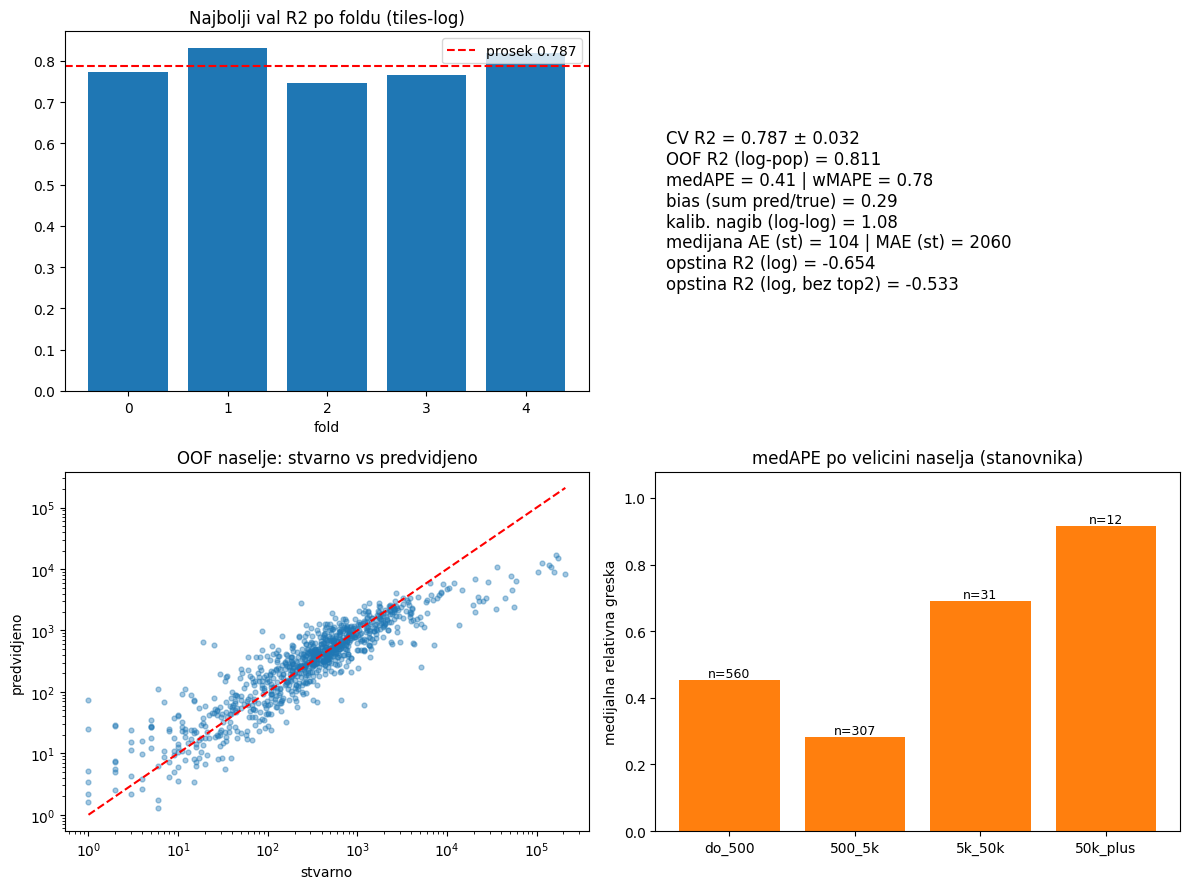

2026/07/24 15:24:55 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/24 15:24:55 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


[tiles-log] CV R2 0.787 ± 0.032 | OOF R2(log) 0.811 | medAPE 0.41 | wMAPE 0.78 | bias 0.29 | opstina R2(log, bez top2) -0.533

=== Rezultat (plocice + agregacija) ===


---------------------------------------------------------------------------
SparkConnectException                     Traceback (most recent call last)
File <command-4719907104565331>, line 3
      1 rezultat = run()
      2 print("\n=== Rezultat (plocice + agregacija) ===")
----> 3 display(pd.DataFrame([rezultat]).set_index("pristup"))

File /databricks/python_shell/lib/dbruntime/display.py:159, in Display.display(self, input, *args, **kwargs)
    157     self.display(input.make_dataframe())
    158 elif type(input).__module__ == 'pandas.core.frame' and type(input).__name__ == 'DataFrame':
--> 159     self.display(self.spark.createDataFrame(input))
    160 elif type(input).__module__ in ('databricks.koalas.frame', 'pyspark.pandas.frame') and \
    161         type(input).__name__ == 'DataFrame':
    162     index_col = kwargs.get('index_col')

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/session.py:608, in SparkSession.createDataFrame(self, data, schema, sa

In [0]:
rezultat = run()
print("\n=== Rezultat (plocice + agregacija) ===")
display(pd.DataFrame([rezultat]).set_index("pristup"))

If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc
2026/07/24 15:25:49 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/24 15:25:49 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/24 15:31:01 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.14.0/ml/model/signatures.html for instructions on setting signature on models.
2026/07/24 15:31:06 INFO mlflow.system_metrics.sy

[fold 0] best val R2 0.788


2026/07/24 15:36:09 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.14.0/ml/model/signatures.html for instructions on setting signature on models.
2026/07/24 15:36:11 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/24 15:36:11 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/07/24 15:36:11 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


[fold 1] best val R2 0.765


2026/07/24 15:41:17 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.14.0/ml/model/signatures.html for instructions on setting signature on models.
2026/07/24 15:41:20 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/24 15:41:20 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


[fold 2] best val R2 0.645


2026/07/24 15:41:20 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/07/24 15:46:31 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.14.0/ml/model/signatures.html for instructions on setting signature on models.
2026/07/24 15:46:34 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/24 15:46:34 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!
2026/07/24 15:46:34 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


[fold 3] best val R2 0.718


2026/07/24 15:51:35 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.14.0/ml/model/signatures.html for instructions on setting signature on models.
2026/07/24 15:51:37 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/24 15:51:37 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


[fold 4] best val R2 0.742


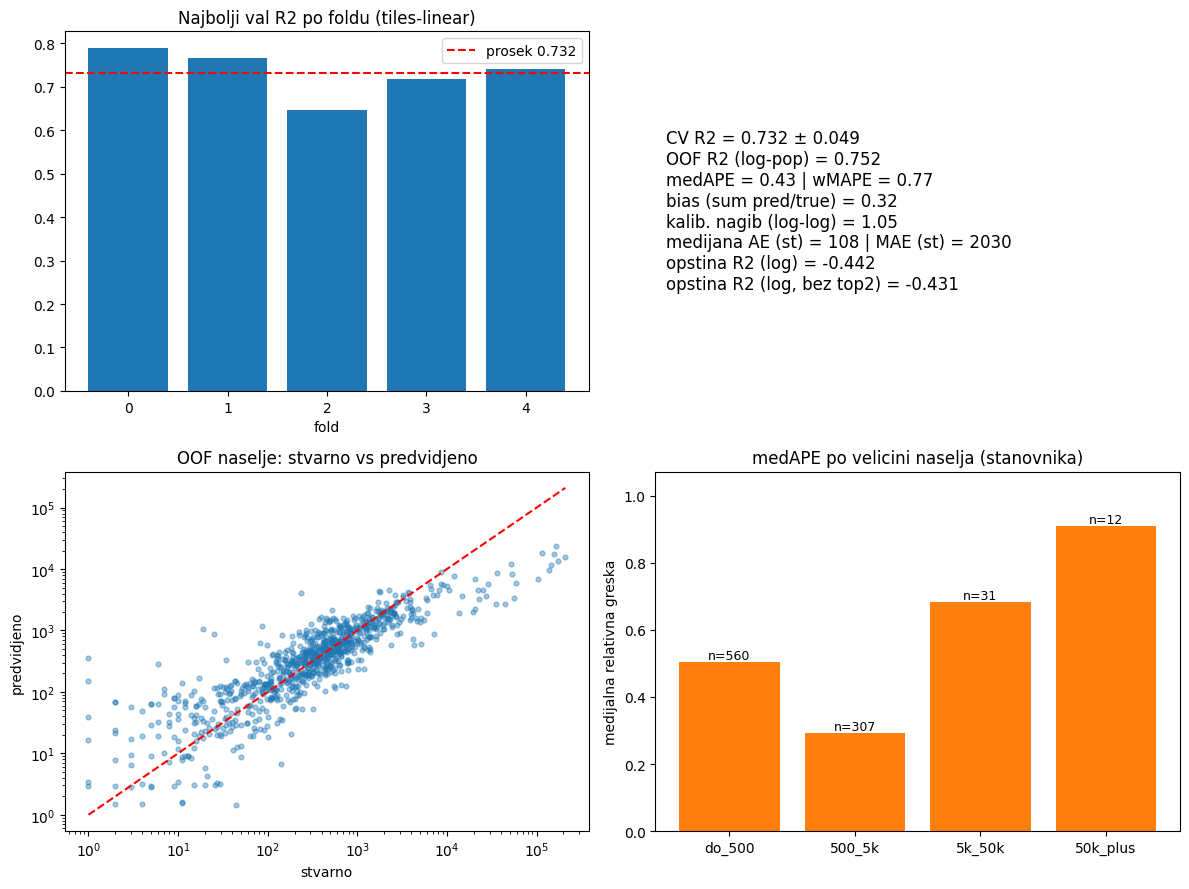

2026/07/24 15:51:39 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/24 15:51:39 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


[tiles-linear] CV R2 0.732 ± 0.049 | OOF R2(log) 0.752 | medAPE 0.43 | wMAPE 0.77 | bias 0.32 | opstina R2(log, bez top2) -0.431

=== Poredjenje log vs linear (agregacioni loss) ===


---------------------------------------------------------------------------
SparkConnectException                     Traceback (most recent call last)
File <command-4719907104565332>, line 10
      4 poredjenje = (
      5     pd.DataFrame([rezultat, rezultat_lin])
      6     .set_index("pristup")
      7     .reindex(columns=GLAVNE_KOLONE)   # reindex: tolerise kljuceve koji eventualno fale
      8 )
      9 print("\n=== Poredjenje log vs linear (agregacioni loss) ===")
---> 10 display(poredjenje)

File /databricks/python_shell/lib/dbruntime/display.py:159, in Display.display(self, input, *args, **kwargs)
    157     self.display(input.make_dataframe())
    158 elif type(input).__module__ == 'pandas.core.frame' and type(input).__name__ == 'DataFrame':
--> 159     self.display(self.spark.createDataFrame(input))
    160 elif type(input).__module__ in ('databricks.koalas.frame', 'pyspark.pandas.frame') and \
    161         type(input).__name__ == 'DataFrame':
    162     index_col = k

In [0]:
# log vs linear loss: isti foldovi i hiperparametri, menja se samo prostor u kom se racuna loss
rezultat_lin = run(loss_space="linear")

poredjenje = (
    pd.DataFrame([rezultat, rezultat_lin])
    .set_index("pristup")
    .reindex(columns=GLAVNE_KOLONE)   # reindex: tolerise kljuceve koji eventualno fale
)
print("\n=== Poredjenje log vs linear (agregacioni loss) ===")
display(poredjenje)